## Cell1 : 환경 설정 및 이미지 로드

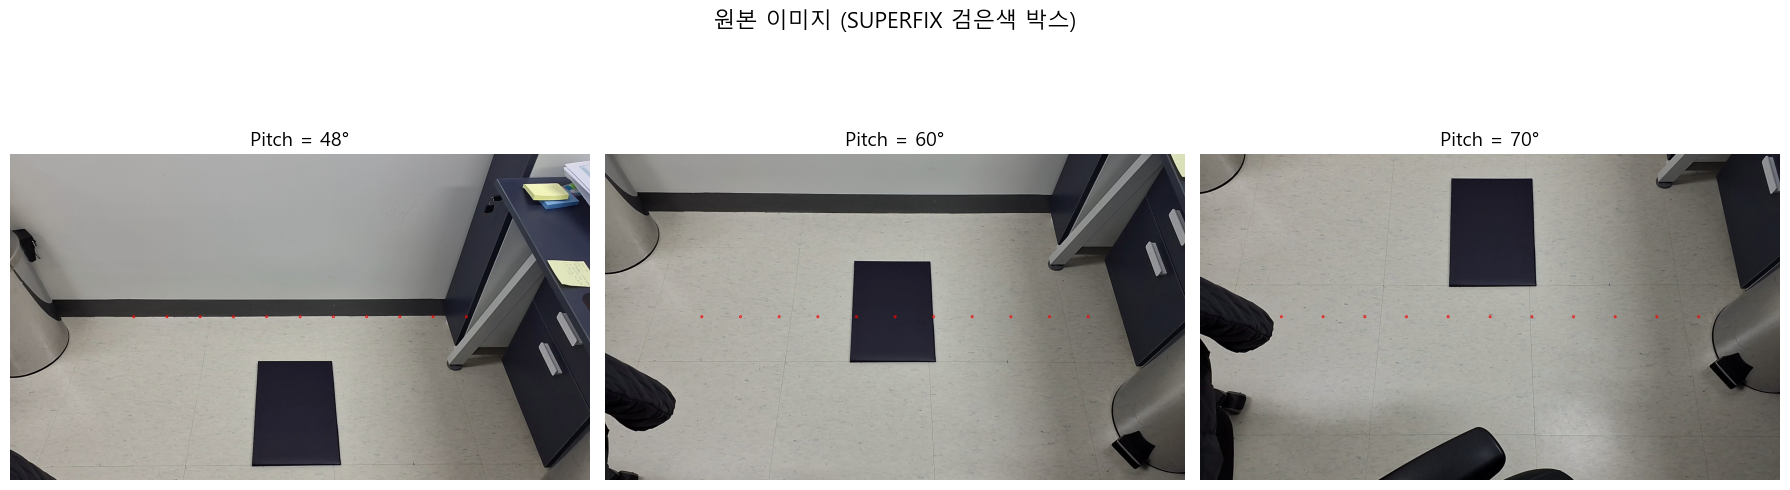

In [7]:
# ── Cell 1: 라이브러리 임포트 및 이미지 로드 ──

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 맑은 고딕 폰트 설정
plt.rcParams['axes.unicode_minus'] = False     # 마이너스(-) 기호 깨짐 방지

# 이미지 경로 설정 (실제 파일명/경로에 맞게 수정하세요)
IMG_DIR = 'images'  # 이미지가 있는 폴더명
IMAGE_FILES = {
    48: os.path.join(IMG_DIR, 'test_20260305_GRD_48degree.jpg'),
    60: os.path.join(IMG_DIR, 'test_20260305_GRD_60degree.jpg'),
    70: os.path.join(IMG_DIR, 'test_20260305_GRD_70degree.jpg'),
}
ANGLES = [48, 60, 70]
REF_ANGLE = 48   # 보정 기준 각도 (정면에 가까운 각도)

# 이미지 로드 및 확인
images = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, angle in zip(axes, ANGLES):
    path = IMAGE_FILES[angle]
    # 파일이 없는 경우를 대비한 예외 처리
    if not os.path.exists(path):
        print(f"경고: 파일을 찾을 수 없습니다 -> {path}")
        # 테스트를 위해 임시로 검은색 더미 이미지를 만듭니다. (실제 환경에서는 삭제하세요)
        img_bgr = np.zeros((1080, 1920, 3), dtype=np.uint8) 
    else:
        img_bgr = cv2.imread(path)
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    images[angle] = img_bgr
    
    ax.imshow(img_rgb)
    ax.set_title(f'Pitch = {angle}°', fontsize=14)
    ax.axis('off')

plt.suptitle('원본 이미지 (SUPERFIX 검은색 박스)', fontsize=16)
plt.tight_layout()
plt.show()

## Cell 2:  박스 세그멘테이션 함수


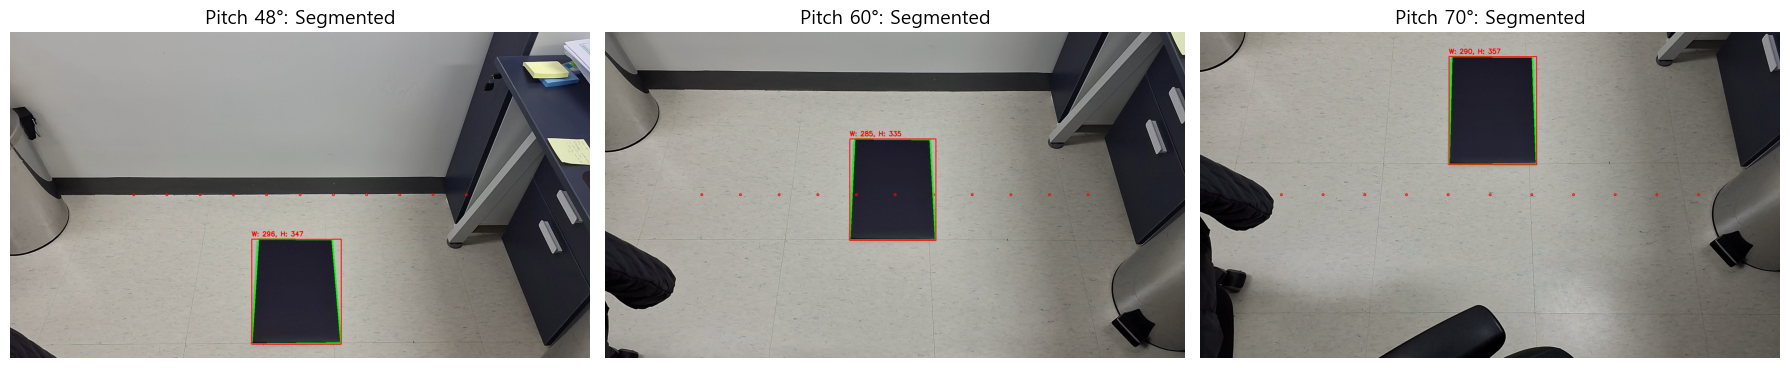

In [18]:
# ── Cell 2: 박스 세그멘테이션 및 시각화 ──

def get_black_box_contour(img_bgr):
    # 1. 그레이스케일 및 블러링 (노이즈 감소)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (9, 9), 0)
    
    # 2. 캐니 엣지 검출 (형태만 추출)
    edged = cv2.Canny(blurred, 30, 150)
    
    # 3. 엣지 연결 (close gaps)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel)
    
    # 4. 윤곽선 찾기
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    img_h, img_w = img_bgr.shape[:2]
    center_x, center_y = img_w // 2, img_h // 2
    
    best_cnt = None
    min_dist = float('inf')
    
    for cnt in contours:
        # 사각형 근사화 (도형의 꼭짓점을 찾아줌)
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.05 * peri, True)
        
        # 사각형(4개의 꼭짓점)인지, 그리고 너무 작지 않은지 확인
        if len(approx) == 4 and cv2.contourArea(cnt) > 2000:
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                
                # 중앙에 가장 가까운 사각형 선택
                dist = np.sqrt((cx - center_x)**2 + (cy - center_y)**2)
                if dist < min_dist:
                    min_dist = dist
                    best_cnt = approx # 사각형 근사치 반환
                    
    return best_cnt

# 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, angle in zip(axes, ANGLES):
    img_bgr = images[angle]
    contour = get_black_box_contour(img_bgr)
    
    # 결과 그리기
    img_display = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    if contour is not None:
        # 박스 사각형 좌표 추출
        x, y, w, h = cv2.boundingRect(contour)
        
        # 윤곽선과 박스 표시
        cv2.drawContours(img_display, [contour], -1, (0, 255, 0), 3)
        cv2.rectangle(img_display, (x, y), (x+w, y+h), (255, 0, 0), 2)
        
        # 정보 출력
        text = f"W: {w}, H: {h}"
        cv2.putText(img_display, text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    
    ax.imshow(img_display)
    ax.set_title(f'Pitch {angle}°: Segmented', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 보정 방법1


In [23]:
class HeightCalibrator:
    def __init__(self, ref_angle, ref_height):
        self.ref_angle = ref_angle
        self.ref_height = ref_height
        self.ratios = {ref_angle: 1.0}

    def update_calibration(self, angle, measured_h):
        """
        새로운 각도와 높이 데이터를 입력받아 캘리브레이션 계수를 자동 갱신
        """
        self.ratios[angle] = self.ref_height / measured_h
        print(f"[{angle}° 캘리브레이션 완료] 배율(Ratio): {self.ratios[angle]:.4f}")

    def get_corrected_h(self, h, angle):
        """
        해당 각도의 배율을 사용하여 보정된 높이 반환
        """
        ratio = self.ratios.get(angle, 1.0)
        return h * ratio

# 1. 초기화: 기준 각도(48°)와 기준 높이(347) 설정
calibrator = HeightCalibrator(ref_angle=48, ref_height=347.0)

# 2. 파라미터화된 데이터 입력 (실측 데이터)
# 이 부분은 나중에 실제 영상 처리 루프에서 실시간으로 호출하면 됩니다.
calibration_data = {60: 335, 70: 357}

for angle, h in calibration_data.items():
    calibrator.update_calibration(angle, h)

# 3. 보정 적용 확인
print("-" * 30)
for angle in [48, 60, 70]:
    h = {48: 347, 60: 335, 70: 357}[angle]
    h_corrected = calibrator.get_corrected_h(h, angle)
    print(f"Pitch {angle}° -> 원본 H: {h}, 보정 후 H: {h_corrected:.2f}")

[60° 캘리브레이션 완료] 배율(Ratio): 1.0358
[70° 캘리브레이션 완료] 배율(Ratio): 0.9720
------------------------------
Pitch 48° -> 원본 H: 347, 보정 후 H: 347.00
Pitch 60° -> 원본 H: 335, 보정 후 H: 347.00
Pitch 70° -> 원본 H: 357, 보정 후 H: 347.00


## 보정 방법2

  Pitch 48°  →  w=296px, h=347px  (좌상단 x=800, y=687)
  Pitch 60°  →  w=285px, h=335px  (좌상단 x=810, y=356)
  Pitch 70°  →  w=290px, h=357px  (좌상단 x=824, y=84)

── 변환 결과 ──
  48° → 60°
    실측  : W=285px,  H=335px
    예측  : W=296px,  H=332px  (scale_w=1.000, scale_h=0.957)
    오차  : W=3.9%,  H=0.9%

  48° → 70°
    실측  : W=290px,  H=357px
    예측  : W=307px,  H=342px  (scale_w=1.037, scale_h=0.986)
    오차  : W=5.9%,  H=4.2%

  60° → 70°
    실측  : W=290px,  H=357px
    예측  : W=296px,  H=347px  (scale_w=1.039, scale_h=1.036)
    오차  : W=2.1%,  H=2.8%



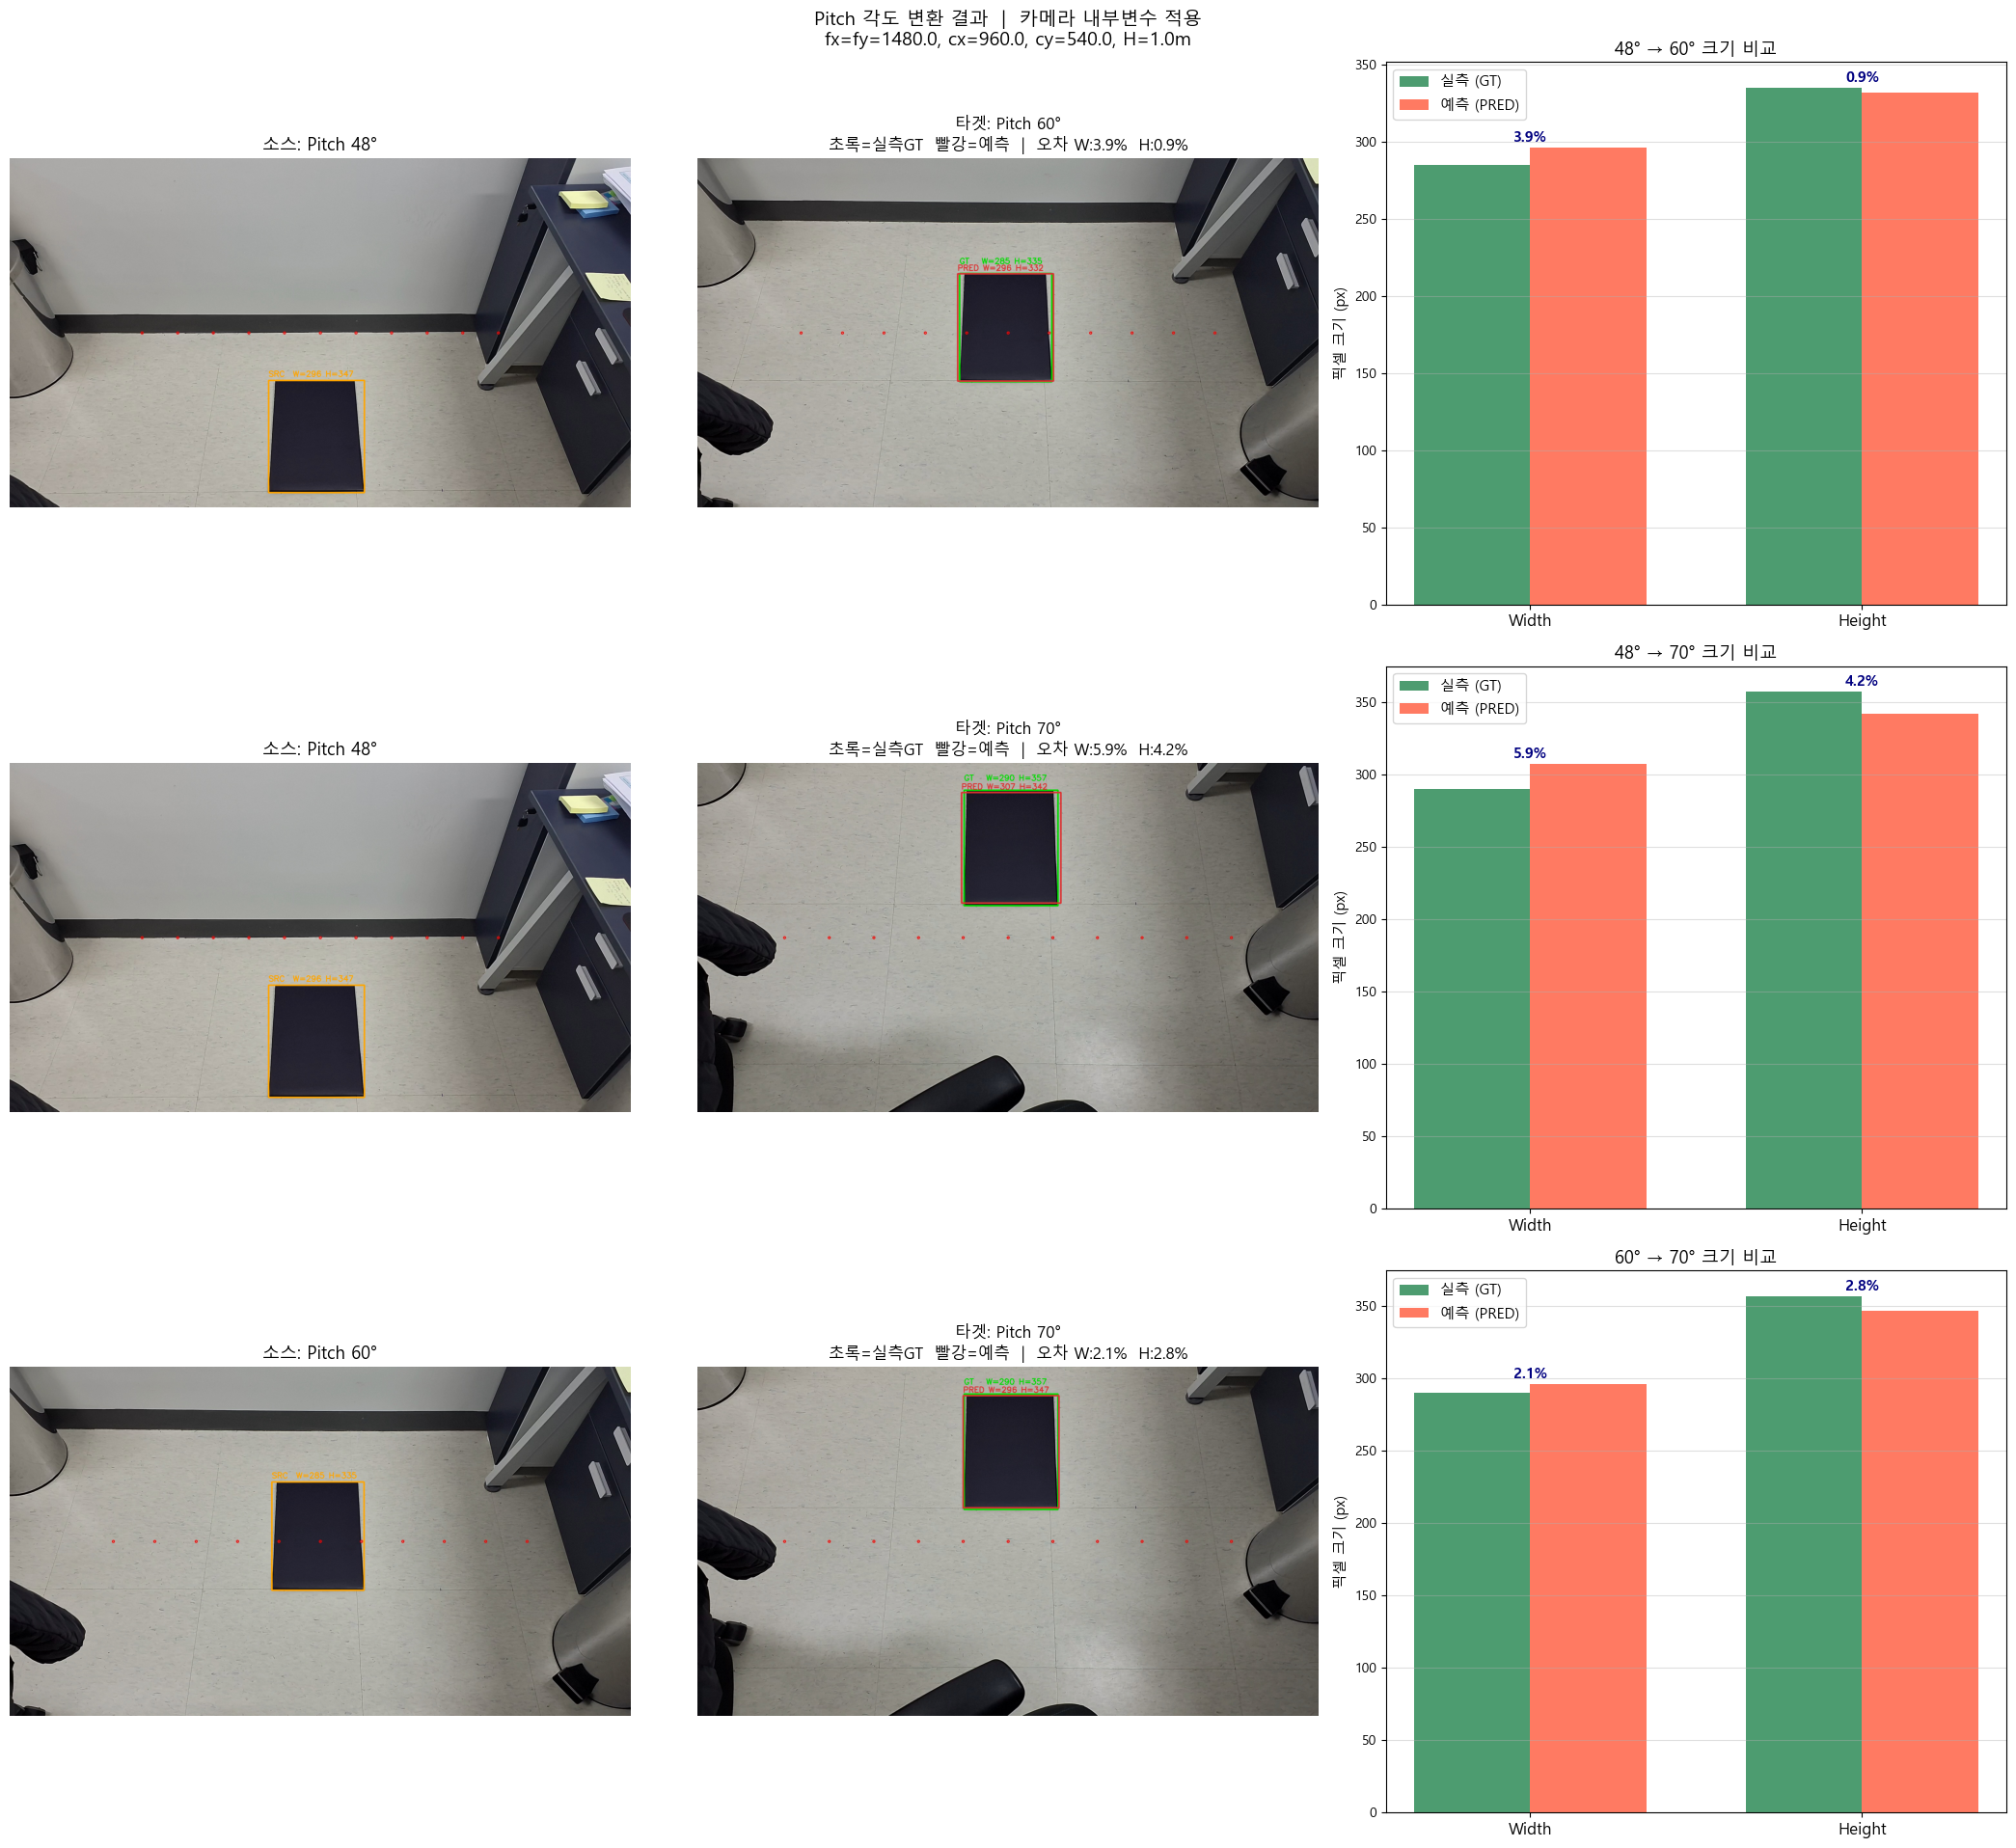

── 각도별 역산 실세계 크기 ──
  카메라 높이: 1.0m  /  fx=fy=1480.0  cx=960.0  cy=540.0
   Pitch │    W_px │    H_px │      실세계 W(m) │      실세계 H(m)
────────────────────────────────────────────────────────────
     48° │     296 │     347 │        0.2252 │        0.2996
     60° │     285 │     335 │        0.2238 │        0.3071
     70° │     290 │     357 │        0.2238 │        0.3154


In [26]:
# ── Cell 3 (카메라 내부변수 적용판): Pitch 각도 보정 함수 및 적용 ──

# ── 3-1. 카메라 파라미터 설정 ──
CAM_HEIGHT_M = 1.0        # 카메라 설치 높이 (m)
FX = 1480.0               # 초점거리 x (픽셀)
FY = 1480.0               # 초점거리 y (픽셀)
CX = 960.0                # 주점 x (픽셀)
CY = 540.0                # 주점 y (픽셀)
IMG_W, IMG_H = 1920, 1080


# ── 3-2. 핵심 기하학 함수 ──

def pixel_to_ray(px, py, fx=FX, fy=FY, cx=CX, cy=CY):
    """
    이미지 픽셀 좌표 → 카메라 좌표계 단위 방향벡터 (ray).
    카메라 좌표: X=오른쪽, Y=아래쪽, Z=앞쪽
    """
    dx = (px - cx) / fx
    dy = (py - cy) / fy
    dz = 1.0
    norm = np.sqrt(dx**2 + dy**2 + dz**2)
    return np.array([dx / norm, dy / norm, dz / norm])


def ray_to_pixel(ray, fx=FX, fy=FY, cx=CX, cy=CY):
    """카메라 좌표계 방향벡터 → 이미지 픽셀 좌표."""
    px = fx * (ray[0] / ray[2]) + cx
    py = fy * (ray[1] / ray[2]) + cy
    return px, py


def pitch_rotation_matrix(delta_pitch_deg):
    """
    카메라 pitch 회전 행렬 (X축 기준 회전).
    delta_pitch_deg > 0 : 아래를 더 내려다보는 방향
    """
    theta = np.radians(delta_pitch_deg)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [1,  0,  0],
        [0,  c, -s],
        [0,  s,  c]
    ])


def ground_intersection(ray_cam, pitch_deg, cam_height=CAM_HEIGHT_M):
    """
    카메라 좌표계 ray → pitch 각도를 고려해 지면(Y=cam_height 월드평면)과의 교점 계산.
    
    카메라는 지면에서 cam_height 높이에 있고,
    pitch_deg 만큼 아래를 바라보고 있다고 가정.
    
    Returns: 월드 좌표 (X, Z) — 지면 상의 위치 (m)
    """
    # 월드 좌표계로 ray 변환 (pitch 회전 적용)
    # 카메라 좌표 Y아래 → 월드 Y위 변환 포함
    R = pitch_rotation_matrix(pitch_deg)
    
    # 카메라 좌표계: Z=앞, Y=아래
    # 월드 좌표계:   Z=앞, Y=위 (지면이 Y=0, 카메라가 Y=cam_height)
    # 변환: world_ray = R @ [rx, -ry, rz]  (Y축 반전 후 pitch 회전)
    ray_world = R @ np.array([ray_cam[0], -ray_cam[1], ray_cam[2]])
    
    # ray_world[1] < 0 이면 지면 방향 (아래)
    if ray_world[1] >= 0:
        return None  # 지면과 교차하지 않음
    
    # 파라미터 t: 카메라위치(0, cam_height, 0) + t * ray_world 가 Y=0 평면과 만남
    t = cam_height / (-ray_world[1])
    x_world = t * ray_world[0]
    z_world = t * ray_world[2]
    return np.array([x_world, z_world])


def world_to_pixel(world_point, pitch_deg,
                   cam_height=CAM_HEIGHT_M,
                   fx=FX, fy=FY, cx=CX, cy=CY):
    """
    월드 좌표 (X, Z) → pitch_deg 카메라 기준 이미지 픽셀 좌표.
    """
    xw, zw = world_point
    # 월드 → 카메라 좌표 (역회전 + 높이 반영)
    # 카메라 위치: (0, cam_height, 0)
    # 오브젝트 월드 위치: (xw, 0, zw) — 지면(Y=0)
    obj_cam_raw = np.array([xw, -cam_height, zw])  # Y 반전 (월드Y위→카메라Y아래)
    
    R = pitch_rotation_matrix(pitch_deg)
    obj_cam = R.T @ obj_cam_raw  # 역회전
    
    if obj_cam[2] <= 0:
        return None
    
    px = fx * (obj_cam[0] / obj_cam[2]) + cx
    py = fy * (obj_cam[1] / obj_cam[2]) + cy
    return px, py


# ── 3-3. bbox 보정 핵심 함수 ──

def correct_bbox_for_pitch(bbox_src, pitch_src_deg, pitch_tgt_deg,
                            cam_height=CAM_HEIGHT_M):
    """
    pitch_src_deg 에서 관측된 bbox를
    pitch_tgt_deg 카메라 기준 픽셀 크기로 변환.

    전략:
      1. bbox 네 꼭짓점 각각을 ray로 변환
      2. ray → 지면 교점 (월드 좌표)
      3. 월드 좌표 → 타겟 pitch 기준 픽셀 좌표로 재투영
      4. 재투영된 좌표로 새 bbox 산출

    Parameters
    ----------
    bbox_src      : (x, y, w, h)
    pitch_src_deg : 소스 pitch (도)
    pitch_tgt_deg : 타겟 pitch (도)
    cam_height    : 카메라 높이 (m)

    Returns
    -------
    bbox_tgt_pred : (x_new, y_new, w_new, h_new)
    scale_w, scale_h : 너비·높이 스케일 인수
    """
    x, y, w, h = bbox_src

    # bbox 네 꼭짓점 (좌상, 우상, 우하, 좌하)
    corners_src = np.array([
        [x,     y    ],
        [x + w, y    ],
        [x + w, y + h],
        [x,     y + h],
    ], dtype=float)

    corners_tgt = []
    for (px, py) in corners_src:
        # 1. 픽셀 → 카메라 ray
        ray = pixel_to_ray(px, py)

        # 2. ray → 지면 월드 좌표
        wp = ground_intersection(ray, pitch_src_deg, cam_height)
        if wp is None:
            # 지면 교차 실패 시 단순 스케일 폴백
            scale_fallback = (np.tan(np.radians(pitch_src_deg)) /
                              np.tan(np.radians(pitch_tgt_deg)))
            cx_b, cy_b = x + w / 2, y + h / 2
            return (int(cx_b - w * scale_fallback / 2),
                    int(cy_b - h * scale_fallback / 2),
                    int(w * scale_fallback),
                    int(h * scale_fallback)), scale_fallback, scale_fallback

        # 3. 월드 좌표 → 타겟 pitch 픽셀
        pt = world_to_pixel(wp, pitch_tgt_deg, cam_height)
        if pt is None:
            pt = (px, py)  # 폴백
        corners_tgt.append(pt)

    corners_tgt = np.array(corners_tgt)

    # 4. 재투영 좌표로 bbox 산출
    x_new = int(round(corners_tgt[:, 0].min()))
    y_new = int(round(corners_tgt[:, 1].min()))
    w_new = int(round(corners_tgt[:, 0].max() - corners_tgt[:, 0].min()))
    h_new = int(round(corners_tgt[:, 1].max() - corners_tgt[:, 1].min()))

    scale_w = w_new / w if w > 0 else 1.0
    scale_h = h_new / h if h > 0 else 1.0

    return (x_new, y_new, w_new, h_new), scale_w, scale_h


def estimate_real_size(bbox, pitch_deg, cam_height=CAM_HEIGHT_M):
    """
    bbox 픽셀 크기 + pitch → 실세계 물체 크기(m) 역산.
    bbox 중심을 기준으로 좌우/상하 1픽셀 이동 후 지면 교점 차이로 계산.
    """
    x, y, w, h = bbox
    cx_b, cy_b = x + w / 2, y + h / 2

    # 너비 역산: 중심에서 좌우 w/2 픽셀 → 지면 X 거리
    ray_l = pixel_to_ray(cx_b - w / 2, cy_b)
    ray_r = pixel_to_ray(cx_b + w / 2, cy_b)
    wp_l  = ground_intersection(ray_l, pitch_deg, cam_height)
    wp_r  = ground_intersection(ray_r, pitch_deg, cam_height)
    real_w = float(np.linalg.norm(wp_r - wp_l)) if (wp_l is not None and wp_r is not None) else None

    # 높이 역산: 중심에서 상하 h/2 픽셀 → 지면 Z 거리
    ray_t = pixel_to_ray(cx_b, cy_b - h / 2)
    ray_b = pixel_to_ray(cx_b, cy_b + h / 2)
    wp_t  = ground_intersection(ray_t, pitch_deg, cam_height)
    wp_b  = ground_intersection(ray_b, pitch_deg, cam_height)
    real_h = float(np.linalg.norm(wp_b - wp_t)) if (wp_t is not None and wp_b is not None) else None

    return real_w, real_h


# ── 3-4. bbox 재수집 ──
detected_bboxes = {}
for angle in ANGLES:
    img_bgr = images[angle]
    cnt = get_black_box_contour(img_bgr)
    if cnt is not None:
        detected_bboxes[angle] = cv2.boundingRect(cnt)
        x, y, w, h = detected_bboxes[angle]
        print(f"  Pitch {angle:2d}°  →  w={w}px, h={h}px  (좌상단 x={x}, y={y})")
    else:
        detected_bboxes[angle] = None
        print(f"  Pitch {angle:2d}°  →  검출 실패")

print()


# ── 3-5. 변환 적용 및 시각화 ──
CONVERSION_PAIRS = [
    (ANGLES[0], ANGLES[1]),   # 48° → 60°
    (ANGLES[0], ANGLES[2]),   # 48° → 70°
    (ANGLES[1], ANGLES[2]),   # 60° → 70°
]

fig, axes = plt.subplots(len(CONVERSION_PAIRS), 3,
                          figsize=(21, 6.5 * len(CONVERSION_PAIRS)))

print("── 변환 결과 ──")
for row, (src_angle, tgt_angle) in enumerate(CONVERSION_PAIRS):
    bbox_src = detected_bboxes.get(src_angle)
    bbox_tgt = detected_bboxes.get(tgt_angle)

    if bbox_src is None or bbox_tgt is None:
        print(f"  {src_angle}° → {tgt_angle}°: bbox 없음, 스킵")
        continue

    # 변환
    bbox_pred, sw, sh = correct_bbox_for_pitch(bbox_src, src_angle, tgt_angle)
    x_p, y_p, w_p, h_p = bbox_pred
    x_t, y_t, w_t, h_t = bbox_tgt

    err_w = abs(w_p - w_t) / max(w_t, 1) * 100
    err_h = abs(h_p - h_t) / max(h_t, 1) * 100

    print(f"  {src_angle}° → {tgt_angle}°")
    print(f"    실측  : W={w_t}px,  H={h_t}px")
    print(f"    예측  : W={w_p}px,  H={h_p}px  (scale_w={sw:.3f}, scale_h={sh:.3f})")
    print(f"    오차  : W={err_w:.1f}%,  H={err_h:.1f}%")
    print()

    # 컬럼 0: 소스
    img_src = cv2.cvtColor(images[src_angle], cv2.COLOR_BGR2RGB).copy()
    xs, ys, ws, hs = bbox_src
    cv2.rectangle(img_src, (xs, ys), (xs+ws, ys+hs), (255, 165, 0), 3)
    cv2.putText(img_src, f"SRC  W={ws} H={hs}",
                (xs, max(ys - 12, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 165, 0), 2)
    axes[row, 0].imshow(img_src)
    axes[row, 0].set_title(f'소스: Pitch {src_angle}°', fontsize=13)
    axes[row, 0].axis('off')

    # 컬럼 1: 타겟 — GT(초록) + 예측(빨강) 중심 정렬 오버레이
    img_tgt = cv2.cvtColor(images[tgt_angle], cv2.COLOR_BGR2RGB).copy()

    # GT (초록)
    cv2.rectangle(img_tgt, (x_t, y_t), (x_t+w_t, y_t+h_t), (0, 220, 0), 3)
    cv2.putText(img_tgt, f"GT   W={w_t} H={h_t}",
                (x_t, max(y_t - 30, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 220, 0), 2)

    # 예측 — GT 중심에 정렬하여 크기만 비교
    cx_t = x_t + w_t // 2
    cy_t = y_t + h_t // 2
    x_ov = cx_t - w_p // 2
    y_ov = cy_t - h_p // 2
    cv2.rectangle(img_tgt, (x_ov, y_ov), (x_ov+w_p, y_ov+h_p), (220, 50, 50), 3)
    cv2.putText(img_tgt, f"PRED W={w_p} H={h_p}",
                (x_ov, max(y_ov - 10, 40)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (220, 50, 50), 2)

    axes[row, 1].imshow(img_tgt)
    axes[row, 1].set_title(
        f'타겟: Pitch {tgt_angle}°\n초록=실측GT  빨강=예측  |  오차 W:{err_w:.1f}%  H:{err_h:.1f}%',
        fontsize=12)
    axes[row, 1].axis('off')

    # 컬럼 2: 막대 그래프
    bar_x  = np.arange(2)
    bw_bar = 0.35
    ax_b   = axes[row, 2]
    ax_b.bar(bar_x - bw_bar/2, [w_t, h_t], bw_bar,
             label='실측 (GT)',   color='seagreen', alpha=0.85)
    ax_b.bar(bar_x + bw_bar/2, [w_p, h_p], bw_bar,
             label='예측 (PRED)', color='tomato',   alpha=0.85)
    ax_b.set_xticks(bar_x)
    ax_b.set_xticklabels(['Width', 'Height'], fontsize=12)
    ax_b.set_ylabel('픽셀 크기 (px)', fontsize=11)
    ax_b.set_title(f'{src_angle}° → {tgt_angle}° 크기 비교', fontsize=13)
    ax_b.legend(fontsize=11)
    ax_b.grid(axis='y', alpha=0.4)
    for xi, (g, p) in enumerate(zip([w_t, h_t], [w_p, h_p])):
        err = abs(p - g) / max(g, 1) * 100
        ax_b.text(xi, max(g, p) + 4, f'{err:.1f}%',
                  ha='center', fontsize=11, color='navy', fontweight='bold')

plt.suptitle(
    'Pitch 각도 변환 결과  |  카메라 내부변수 적용\n'
    f'fx=fy={FX}, cx={CX}, cy={CY}, H={CAM_HEIGHT_M}m',
    fontsize=14)
plt.tight_layout()
plt.show()


# ── 3-6. 실세계 크기 역산 검증 ──
print("── 각도별 역산 실세계 크기 ──")
print(f"  카메라 높이: {CAM_HEIGHT_M}m  /  fx=fy={FX}  cx={CX}  cy={CY}")
print(f"{'Pitch':>8} │ {'W_px':>7} │ {'H_px':>7} │ {'실세계 W(m)':>13} │ {'실세계 H(m)':>13}")
print("─" * 60)
for angle in ANGLES:
    bb = detected_bboxes.get(angle)
    if bb:
        rw, rh = estimate_real_size(bb, angle)
        rw_str = f"{rw:.4f}" if rw is not None else "N/A"
        rh_str = f"{rh:.4f}" if rh is not None else "N/A"
        print(f"{angle:>7}° │ {bb[2]:>7} │ {bb[3]:>7} │ {rw_str:>13} │ {rh_str:>13}")